## Laboratorio 6
### KNN

**Preparar el entorno**

In [7]:
# Librerias que se van a usar

import importlib, subprocess, sys

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "pyreadr": "pyreadr",
    "seaborn": "seaborn"
}

# Si falta alguna libreria, se instala en el momento
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.import_module(module)

from sklearn.linear_model import BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pyreadr

**Cargar dataset y dividirlo**

In [8]:
# Se carga el dataset desde el archivo .RData
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Se limpia la columna price (se quitan simbolos y se dejan solo numeros)
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)

# Se convierte price a numerico
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Se conservan solo filas con precio valido
n_before = len(df)
mask_valid_price = df['price'].notna() & (df['price'] > 0)
df_clean = df.loc[mask_valid_price].copy()
n_after = len(df_clean)
print(f"Filas totales: {n_before}, después limpieza price: {n_after} (eliminadas {n_before-n_after})")

# Se trabaja con log(price) para modelar y visualizar los resultados de mejor manera
df_model = df_clean.copy()
df_model['log_price'] = np.log(df_model['price'])

# Se asegura que estas columnas esten en formato numerico
for col in ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Variables base del modelo
features = ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
X = df_model[features].copy()

# Si existe room_type, se pasa a dummies
if 'room_type' in df_model.columns:
    dummies = pd.get_dummies(df_model['room_type'], drop_first=True)
    X = pd.concat([X, dummies], axis=1)

y = df_model['log_price'].copy()

# Se rellenan faltantes con la mediana de cada columna
X = X.fillna(X.median())

# Se mantiene el mismo split que en otros modelos para poder comparar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de los datos")
print(f"Conjunto de Entrenamiento: {X_train.shape[0]} filas.")
print(f"Conjunto de Prueba: {X_test.shape[0]} filas.\n")

Filas totales: 171748, después limpieza price: 76246 (eliminadas 95502)
Dimensiones de los datos
Conjunto de Entrenamiento: 60996 filas.
Conjunto de Prueba: 15250 filas.



## Actividades:
1. Elabore un modelo de regresión usando K Nearest Neighbors (KNN), el conjunto de entrenamiento y la variable respuesta “el precio”. 
Prediga con el modelo y explique los resultados a los que llega. Asegúrese que los conjuntos de entrenamiento y prueba sean los mismos de las entregas anteriores para que los modelos sean comparables.
2. Analice los resultados del modelo de regresión usando KNN. ¿Qué tan bien le fue prediciendo? Utilice las métricas correctas.

Modelo de Regresión KNN
R2 (log): 0.4245
MAE (USD): $550.06
RMSE (USD): $3675.89



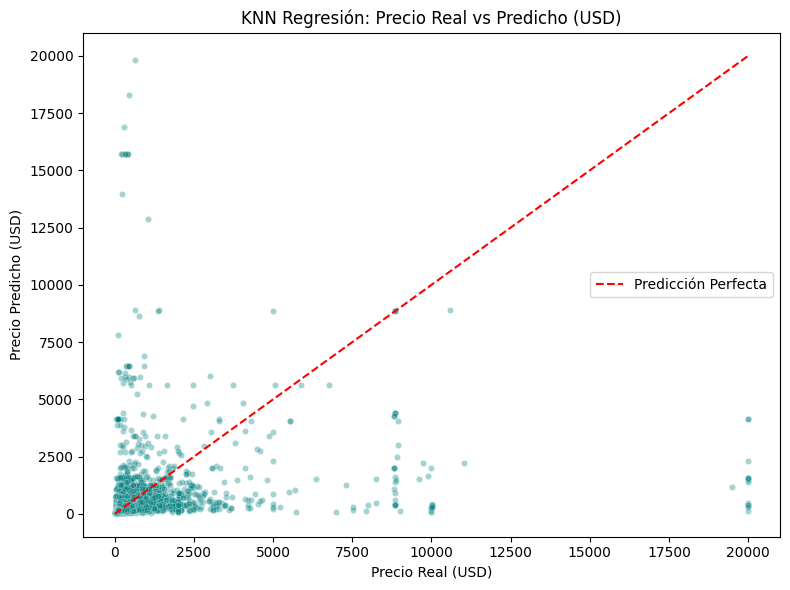

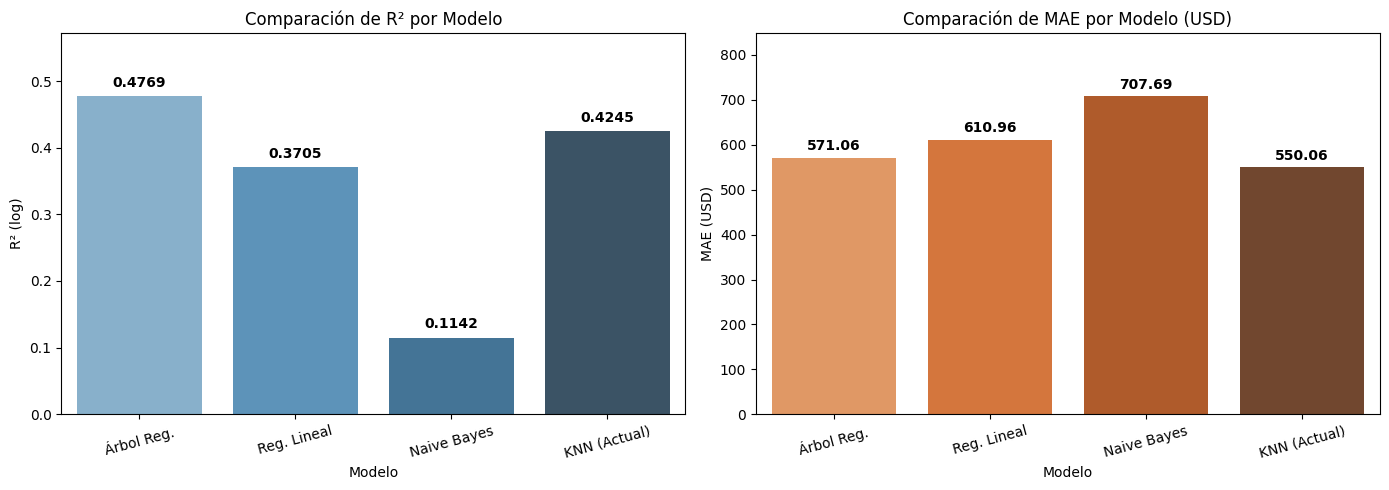

In [9]:
# Escalar los datos para KNN

scaler_reg = StandardScaler()

# X_train y X_test son variables predictoras de labs anteriores.
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print("Modelo de Regresión KNN")

# Se instancia el modelo (k=5 por defecto para este primer acercamiento)
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)  # y_train es log_price

# Predicción
y_pred_log_knn = knn_reg.predict(X_test_scaled)

# Transformamos de vuelta a dólares para evaluar el MAE y RMSE
y_test_usd = np.exp(y_test).to_numpy()
y_pred_usd_knn = np.exp(y_pred_log_knn)

# Cálculo de métricas
r2_knn_log = r2_score(y_test, y_pred_log_knn)
mae_knn_usd = mean_absolute_error(y_test_usd, y_pred_usd_knn)
rmse_knn_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd_knn))

print(f"R2 (log): {r2_knn_log:.4f}")
print(f"MAE (USD): ${mae_knn_usd:.2f}")
print(f"RMSE (USD): ${rmse_knn_usd:.2f}\n")

# Gráficas

# Primera gráfica
# Recortamos al percentil 99 para que los valores extremos no aplasten la visualización
upper_limit = np.nanpercentile(y_test_usd, 99)
plot_df = pd.DataFrame({'Real_USD': y_test_usd, 'Pred_USD': y_pred_usd_knn}).reset_index(drop=True)
plot_df = plot_df[(plot_df['Real_USD'] <= upper_limit) & (plot_df['Pred_USD'] <= upper_limit)]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='Real_USD', y='Pred_USD', alpha=0.35, s=20, color='teal')
plt.plot([0, upper_limit], [0, upper_limit], '--r', linewidth=1.5, label='Predicción Perfecta')
plt.title('KNN Regresión: Precio Real vs Predicho (USD)')
plt.xlabel('Precio Real (USD)')
plt.ylabel('Precio Predicho (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# Segunda gráfica
R2_KNN_LOG = r2_knn_log
MAE_KNN_USD = mae_knn_usd

modelos = ['Árbol Reg.', 'Reg. Lineal', 'Naive Bayes', 'KNN (Actual)']
r2_scores = [0.4769, 0.3705, 0.1142, R2_KNN_LOG]
mae_scores = [571.06, 610.96, 707.69, MAE_KNN_USD]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: R2
r2_df = pd.DataFrame({'Modelo': modelos, 'R2': r2_scores})
sns.barplot(data=r2_df, x='Modelo', y='R2', hue='Modelo', dodge=False, legend=False,
            ax=axes[0], palette='Blues_d')
axes[0].set_title('Comparación de R² por Modelo')
axes[0].set_ylabel('R² (log)')
axes[0].set_ylim(0, max(r2_scores) * 1.2)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

# Panel 2: MAE
mae_df = pd.DataFrame({'Modelo': modelos, 'MAE': mae_scores})
sns.barplot(data=mae_df, x='Modelo', y='MAE', hue='Modelo', dodge=False, legend=False,
            ax=axes[1], palette='Oranges_d')
axes[1].set_title('Comparación de MAE por Modelo (USD)')
axes[1].set_ylabel('MAE (USD)')
axes[1].set_ylim(0, max(mae_scores) * 1.2)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 10, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()